# 📊 TEST & ĐÁNH GIÁ CHI TIẾT — trên tập TEST

**Cấu phần (ii)** · Dự án Competitor Fare Forecasting (GSM)

Notebook này **chỉ để đánh giá** trên tập test (16–18/12, model chưa từng thấy). Cho ra **số liệu
USD cụ thể** để viết báo cáo: sai số thật, độ chính xác, case chi tiết, sai số theo lát cắt.

> Chạy `data_preparation.ipynb` và `model_train.ipynb` trước (hoặc notebook này tự train lại
> nếu chưa có model). Kết quả xuất ra bảng + biểu đồ + file CSV chi tiết trong `../data/`.

## Mục lục
1. Nạp dữ liệu & model
2. Dự đoán trên tập test
3. Chỉ số tổng hợp (USD) — Model GIÁ
4. Độ chính xác: sai số nằm trong ngưỡng bao nhiêu?
5. 10 case chi tiết — GIÁ
6. Chỉ số Model HỆ SỐ NHÂN
7. 10 case chi tiết — HỆ SỐ NHÂN
8. Sai số theo lát cắt (giờ / độ trễ / tuyến)
9. Xuất file CSV kết quả

---
# 1️⃣ Nạp dữ liệu & model

Ưu tiên load model `.joblib` đã lưu; nếu lỗi (phiên bản sklearn khác) thì **train lại tại chỗ**
với đúng cấu hình — kết quả như nhau.

In [1]:
import warnings, numpy as np, pandas as pd, joblib
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             roc_auc_score, average_precision_score, brier_score_loss)
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline
BLUE, RED, GREEN, MUT = "#0072B2", "#D55E00", "#009E73", "#666666"
MAU_HANG = {"Uber": BLUE, "Lyft": RED}
plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.color":"#ECECEC","font.size":10})
pd.set_option("display.width", 240); pd.set_option("display.max_columns", 40)
DATA = Path("../data"); MODEL = Path(".")

gp = pd.read_csv(DATA/"snapshot_price_15min.csv", parse_dates=["snapshot"])
gs = pd.read_csv(DATA/"snapshot_surge_15min.csv", parse_dates=["snapshot"])
print(f"Nap: price {len(gp):,} dong | surge {len(gs):,} dong")

# Feature set (khop model_train.ipynb)
PC = ["name","source","destination","observation_age_bucket"]
PN = ["distance_median","lag1_price","lag2_price","lag3_price","roll_mean6_price",
      "roll_std3_price","observation_age_minutes","hour_local","weekday_local","is_weekend"]
SC = ["source","destination","short_summary"]
SN = ["hour_local","weekday_local","is_weekend","lag1_surge","lag2_surge",
      "roll_mean6_surge","roll_surge_rate6","observation_age_minutes"]
PF, SF = PC+PN, SC+SN
def prep(df, cat):
    X = df.copy()
    for c in cat: X[c] = X[c].astype("category")
    return X

Nap: price 471,649 dong | surge 66,445 dong


In [2]:
# Load model .joblib; neu loi phien ban -> train lai tai cho
def load_hoac_train():
    try:
        mu = joblib.load(MODEL/"model_price_uber.joblib")
        ml = joblib.load(MODEL/"model_price_lyft.joblib")
        clf, reg = joblib.load(MODEL/"model_surge_lyft.joblib")
        # test thu 1 predict de chac chan tuong thich
        _ = mu.predict(prep(gp[gp.cab_type=="Uber"].head(5), PC)[PF])
        print("Da load model tu file .joblib")
        return mu, ml, clf, reg
    except Exception as e:
        print(f"Khong load duoc .joblib ({type(e).__name__}) -> TRAIN LAI tai cho...")
        def tp(hang):
            tr = gp[(gp.cab_type==hang)&(gp.data_split=="train")]
            m = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05, l2_regularization=1.0,
                early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
                categorical_features=PC, random_state=42)
            return m.fit(prep(tr,PC)[PF], np.log(tr.target_price))
        mu, ml = tp("Uber"), tp("Lyft")
        trs = gs[gs.data_split=="train"]
        clf = HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05, l2_regularization=1.0,
            early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
            categorical_features=SC, random_state=42).fit(prep(trs,SC)[SF], trs.target_is_surge)
        tso = trs[trs.target_is_surge==1]
        reg = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, l2_regularization=1.0,
            categorical_features=SC, random_state=42).fit(prep(tso,SC)[SF], tso.target_surge)
        return mu, ml, clf, reg

m_uber, m_lyft, clf, reg = load_hoac_train()

Da load model tu file .joblib


---
# 2️⃣ Dự đoán trên tập test

Tập test = 16–18/12 (`data_split == "test"`). Giá dự đoán = `exp(model.predict(X))` (vì train
log-target). Tính sẵn cột **sai số USD** cho từng dòng.

In [3]:
tests = {}
for hang, m in [("Uber", m_uber), ("Lyft", m_lyft)]:
    te = gp[(gp.cab_type==hang) & (gp.data_split=="test")].copy()
    te["gia_du_doan"]     = np.exp(m.predict(prep(te, PC)[PF]))
    te["sai_so"]          = te.gia_du_doan - te.target_price        # +: du doan cao hon
    te["sai_so_tuyet_doi"]= te.sai_so.abs()
    te["sai_so_pct"]      = te.sai_so_tuyet_doi / te.target_price * 100
    tests[hang] = te
    print(f"{hang}: {len(te):,} dong test | gia thuc TB {te.target_price.mean():.2f} USD "
          f"| gia du doan TB {te.gia_du_doan.mean():.2f} USD")

# Surge
te_s = gs[gs.data_split=="test"].copy()
te_s["P_surge"]       = clf.predict_proba(prep(te_s, SC)[SF])[:, 1]
te_s["do_lon_du_doan"]= reg.predict(prep(te_s, SC)[SF])
te_s["surge_du_doan"] = te_s.P_surge * te_s.do_lon_du_doan + (1 - te_s.P_surge) * 1.0
te_s["surge_sai_so"]  = te_s.surge_du_doan - te_s.target_surge
print(f"Surge: {len(te_s):,} dong test | ty le surge thuc {te_s.target_is_surge.mean()*100:.2f}%")

Uber: 43,767 dong test | gia thuc TB 15.79 USD | gia du doan TB 15.70 USD
Lyft: 40,914 dong test | gia thuc TB 17.33 USD | gia du doan TB 17.14 USD
Surge: 12,354 dong test | ty le surge thuc 13.53%


---
# 3️⃣ Chỉ số tổng hợp (USD) — Model GIÁ

| Chỉ số | Ý nghĩa |
|---|---|
| **MAE** | Sai số tuyệt đối trung bình — *"trung bình lệch bao nhiêu USD"* |
| **RMSE** | Căn bậc 2 sai số bình phương — phạt lỗi lớn nặng hơn |
| **R²** | % phương sai giải thích được (1 = hoàn hảo) |
| **MAPE** | Sai số tương đối trung bình (%) |
| **Bias** | Lệch trung bình có dấu (+ = dự đoán cao hơn thực tế) |
| **vs baseline** | Giảm bao nhiêu % MAE so với persistence / historical-avg |

In [4]:
rows = []
for hang in ["Uber","Lyft"]:
    te = tests[hang]; y, p = te.target_price.values, te.gia_du_doan.values
    b1, b2 = te.lag1_price.notna(), te.roll_mean6_price.notna()
    per = mean_absolute_error(te.target_price[b1], te.lag1_price[b1])
    his = mean_absolute_error(te.target_price[b2], te.roll_mean6_price[b2])
    mae = mean_absolute_error(y, p)
    rows.append({"Hang":hang, "n_test":len(te),
        "MAE (USD)":round(mae,3), "RMSE (USD)":round(mean_squared_error(y,p)**.5,3),
        "R2":round(r2_score(y,p),4), "MAPE (%)":round(np.mean(np.abs((y-p)/y))*100,2),
        "Bias (USD)":round(np.mean(p-y),3),
        "MAE persist":round(per,3), "MAE histavg":round(his,3),
        "vs persist":f"{(1-mae/per)*100:+.1f}%", "vs histavg":f"{(1-mae/his)*100:+.1f}%"})
bang_gia = pd.DataFrame(rows)
print("CHI SO MODEL GIA (tap test):")
display(bang_gia)

CHI SO MODEL GIA (tap test):


,Hang,n_test,MAE (USD),RMSE (USD),R2,MAPE (%),Bias (USD),MAE persist,MAE histavg,vs persist,vs histavg
0,Uber,43767,1.089,1.810,0.9552,7.37,-0.090,1.683,1.325,+35.3%,+17.8%
1,Lyft,40914,1.502,2.932,0.9142,9.71,-0.195,2.125,1.775,+29.3%,+15.4%


---
# 4️⃣ Độ chính xác: sai số nằm trong ngưỡng bao nhiêu?

Ngoài trung bình, cần biết **phân bố** sai số: bao nhiêu % chuyến dự đoán sai < 0,5 / 1 / 2 USD.
Đây là con số dễ hiểu nhất để đánh giá *"model đoán sát tới đâu"*.

In [5]:
print("PHAN BO SAI SO TUYET DOI (USD) — cac phan vi:")
q = []
for hang in ["Uber","Lyft"]:
    e = tests[hang].sai_so_tuyet_doi
    q.append({"Hang":hang, "p50 (trung vi)":round(e.median(),2), "p75":round(e.quantile(.75),2),
              "p90":round(e.quantile(.9),2), "p95":round(e.quantile(.95),2), "max":round(e.max(),2)})
display(pd.DataFrame(q))

print("\nTY LE CHUYEN DU DOAN DUNG TRONG NGUONG:")
rows = []
for hang in ["Uber","Lyft"]:
    e = tests[hang].sai_so_tuyet_doi
    rows.append({"Hang":hang,
        "<= 0.5 USD":f"{(e<=0.5).mean()*100:.1f}%", "<= 1 USD":f"{(e<=1).mean()*100:.1f}%",
        "<= 2 USD":f"{(e<=2).mean()*100:.1f}%", "<= 3 USD":f"{(e<=3).mean()*100:.1f}%",
        "> 5 USD (lech lon)":f"{(e>5).mean()*100:.1f}%"})
display(pd.DataFrame(rows))

PHAN BO SAI SO TUYET DOI (USD) — cac phan vi:


,Hang,p50 (trung vi),p75,p90,p95,max
0,Uber,0.73,1.31,2.27,3.19,47.16
1,Lyft,0.85,1.71,3.05,4.46,45.53



TY LE CHUYEN DU DOAN DUNG TRONG NGUONG:


,Hang,<= 0.5 USD,<= 1 USD,<= 2 USD,<= 3 USD,> 5 USD (lech lon)
0,Uber,35.6%,63.9%,87.4%,94.3%,1.9%
1,Lyft,32.1%,56.0%,79.9%,89.7%,4.2%


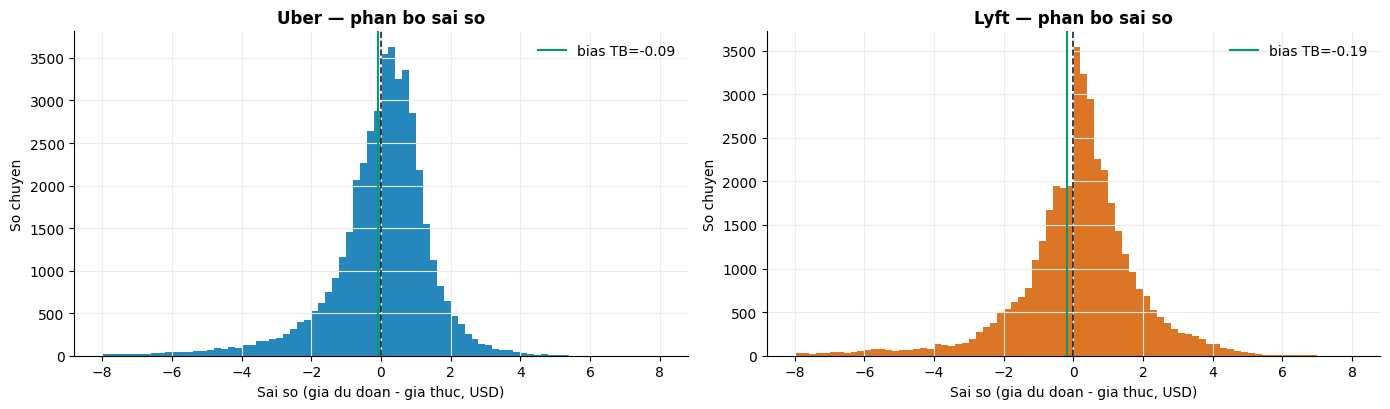

In [6]:
# Bieu do phan bo sai so
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, hang in zip(axes, ["Uber","Lyft"]):
    e = tests[hang].sai_so
    ax.hist(e, bins=80, range=(-8,8), color=MAU_HANG[hang], alpha=.85)
    ax.axvline(0, color="#222", ls="--", lw=1.2)
    ax.axvline(e.mean(), color=GREEN, lw=1.5, label=f"bias TB={e.mean():+.2f}")
    ax.set_xlabel("Sai so (gia du doan - gia thuc, USD)"); ax.set_ylabel("So chuyen")
    ax.set_title(f"{hang} — phan bo sai so", fontweight="bold"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

---
# 5️⃣ 10 case chi tiết — GIÁ

Quan sát trực tiếp: giá quan sát gần nhất (`lag1`), **giá thực**, **giá dự đoán**, sai số USD và %.

In [7]:
cols = ["snapshot","cab_type","source","destination","name",
        "lag1_price","target_price","gia_du_doan","sai_so","sai_so_pct"]
mau = pd.concat([tests["Uber"].sample(5, random_state=7),
                 tests["Lyft"].sample(5, random_state=7)])[cols].copy()
mau.columns = ["Thoi diem","Hang","Diem don","Diem den","Dich vu",
               "Gia truoc (lag1)","GIA THUC","GIA DU DOAN","Sai so (USD)","Sai so (%)"]
for c in ["Gia truoc (lag1)","GIA THUC","GIA DU DOAN","Sai so (USD)","Sai so (%)"]:
    mau[c] = mau[c].round(2)
print("10 CASE CHI TIET — GIA (5 Uber + 5 Lyft):")
display(mau)

10 CASE CHI TIET — GIA (5 Uber + 5 Lyft):


,Thoi diem,Hang,Diem don,Diem den,Dich vu,Gia truoc (lag1),GIA THUC,GIA DU DOAN,Sai so (USD),Sai so (%)
362501,2018-12-17 23:30:00,Uber,North End,North Station,UberPool,7.5,6.5,6.63,0.13,1.97
345001,2018-12-16 02:15:00,Uber,Haymarket Square,Theatre District,Black SUV,27.0,27.5,26.98,-0.52,1.90
233253,2018-12-17 19:00:00,Uber,Back Bay,Fenway,Black,16.0,16.0,15.57,-0.43,2.69
273911,2018-12-16 18:45:00,Uber,Boston University,Beacon Hill,Black SUV,31.5,31.5,31.60,0.10,0.30
357554,2018-12-18 08:30:00,Uber,North End,Beacon Hill,WAV,10.5,10.5,10.59,0.09,0.90
92761,2018-12-17 16:45:00,Lyft,Financial District,South Station,Lux,11.0,11.0,11.13,0.13,1.22
1521,2018-12-17 05:15:00,Lyft,Back Bay,Boston University,Lux Black XL,32.5,27.5,27.92,0.42,1.51
17454,2018-12-16 21:15:00,Lyft,Back Bay,South Station,Lux Black XL,27.5,27.5,27.66,0.16,0.59
180566,2018-12-18 09:00:00,Lyft,South Station,Financial District,Lyft,5.0,5.0,7.03,2.03,40.66
86901,2018-12-16 13:00:00,Lyft,Financial District,North End,Lux Black,16.5,16.5,16.87,0.37,2.23


---
# 6️⃣ Chỉ số Model HỆ SỐ NHÂN (Lyft)

Bài toán **mất cân bằng** (chỉ ~13,5% có surge) → dùng ROC-AUC/PR-AUC, **không dùng accuracy**.
Điểm forecast (E[mult]) so với baseline "luôn đoán 1.0".

In [8]:
y_is = te_s.target_is_surge.values; ps = te_s.P_surge.values
auc_pers = roc_auc_score(y_is, (te_s.lag1_surge.fillna(1)-1).clip(0))
bang_surge = pd.DataFrame([
    {"Chi so":"ROC-AUC","Model":round(roc_auc_score(y_is,ps),4),"Baseline":round(auc_pers,4),
     "Danh gia":"co tin hieu" if roc_auc_score(y_is,ps)>auc_pers else "khong"},
    {"Chi so":"PR-AUC","Model":round(average_precision_score(y_is,ps),4),"Baseline":round(y_is.mean(),4),
     "Danh gia":"nhinh hon nen"},
    {"Chi so":"Brier","Model":round(brier_score_loss(y_is,ps),4),"Baseline":"—","Danh gia":"(cho muc iii)"},
    {"Chi so":"MAE E[mult]","Model":round(mean_absolute_error(te_s.target_surge,te_s.surge_du_doan),4),
     "Baseline":round(mean_absolute_error(te_s.target_surge,np.ones(len(te_s))),4),"Danh gia":"thua hang so (tran that)"},
    {"Chi so":"RMSE E[mult]","Model":round(mean_squared_error(te_s.target_surge,te_s.surge_du_doan)**.5,4),
     "Baseline":"—","Danh gia":"—"},
])
print(f"n_test={len(te_s):,} | ty le surge thuc={y_is.mean()*100:.2f}%")
display(bang_surge)

n_test=12,354 | ty le surge thuc=13.53%


,Chi so,Model,Baseline,Danh gia
0,ROC-AUC,0.6524,0.5181,co tin hieu
1,PR-AUC,0.1898,0.1353,nhinh hon nen
2,Brier,0.1133,—,(cho muc iii)
3,MAE E[mult],0.0644,0.0396,thua hang so (tran that)
4,RMSE E[mult],0.1312,—,—


---
# 7️⃣ 10 case chi tiết — HỆ SỐ NHÂN

5 case **có surge** + 5 case **không surge**. Cột `P_surge` = xác suất model đoán có surge;
`surge_du_doan` = kỳ vọng hệ số nhân.

In [9]:
cs = ["snapshot","source","destination","lag1_surge","target_surge",
      "P_surge","surge_du_doan","surge_sai_so"]
casem = pd.concat([te_s[te_s.target_is_surge==1].sample(5, random_state=3),
                   te_s[te_s.target_is_surge==0].sample(5, random_state=3)])[cs].copy()
casem.columns = ["Thoi diem","Diem don","Diem den","Surge truoc (lag1)",
                 "SURGE THUC","P(surge)","SURGE DU DOAN","Sai so"]
for c in ["Surge truoc (lag1)","SURGE THUC","P(surge)","SURGE DU DOAN","Sai so"]:
    casem[c] = casem[c].round(3)
print("10 CASE — HE SO NHAN (5 co surge + 5 khong):")
display(casem)
print("\nNhan xet: khi surge thuc cao (1.4-1.5), model thuong doan ~1.05 -> hut. Vi surge hiem +")
print("khong dai dang, gia tri model nam o cot P(surge) (khu hay surge -> P cao hon), khong o diem.")

10 CASE — HE SO NHAN (5 co surge + 5 khong):


,Thoi diem,Diem don,Diem den,Surge truoc (lag1),SURGE THUC,P(surge),SURGE DU DOAN,Sai so
55222,2018-12-16 19:45:00,South Station,West End,1.000,1.083,0.116,1.023,-0.060
4450,2018-12-16 22:00:00,Back Bay,Northeastern University,1.000,1.500,0.189,1.045,-0.455
762,2018-12-16 06:15:00,Back Bay,Boston University,1.000,1.417,0.222,1.073,-0.344
5441,2018-12-18 06:15:00,Back Bay,South Station,1.000,1.016,0.250,1.051,0.035
57928,2018-12-16 03:30:00,Theatre District,Haymarket Square,1.000,1.400,0.163,1.067,-0.333
49722,2018-12-17 22:15:00,Northeastern University,West End,1.000,1.000,0.170,1.054,0.054
30321,2018-12-16 07:00:00,Haymarket Square,Financial District,1.000,1.000,0.039,1.006,0.006
22038,2018-12-17 23:00:00,Fenway,West End,1.375,1.000,0.147,1.066,0.066
25767,2018-12-18 10:30:00,Financial District,North End,1.000,1.000,0.143,1.026,0.026
32232,2018-12-17 11:00:00,Haymarket Square,Theatre District,1.000,1.000,0.044,1.006,0.006



Nhan xet: khi surge thuc cao (1.4-1.5), model thuong doan ~1.05 -> hut. Vi surge hiem +
khong dai dang, gia tri model nam o cot P(surge) (khu hay surge -> P cao hon), khong o diem.


---
# 8️⃣ Sai số theo lát cắt (chuẩn bị cho cấu phần iii)

Sai số **không đồng đều** — xem MAE theo giờ cao điểm, theo độ trễ quan sát, theo tuyến. Giúp
biết model yếu ở đâu và interval cần nới ở đâu (phần iii).

In [10]:
# (a) MAE theo do tre quan sat
print("MAE theo DO TRE quan sat (USD):")
order = ["<=15p","15-30p","30-60p","1-3h",">3h"]
rows = []
for hang in ["Uber","Lyft"]:
    te = tests[hang]
    for b in order:
        x = te[te.observation_age_bucket==b]
        if len(x) < 20: continue
        rows.append({"Hang":hang,"Do tre":b,"n":len(x),
                     "MAE model":round(x.sai_so_tuyet_doi.mean(),3)})
display(pd.DataFrame(rows).pivot(index="Do tre", columns="Hang", values="MAE model").reindex(order))

# (b) MAE theo gio (gom nhom)
print("\nMAE theo GIO trong ngay (USD) — Lyft:")
te = tests["Lyft"].copy()
by_h = te.groupby("hour_local").sai_so_tuyet_doi.mean().round(3)
display(by_h.to_frame("MAE").T)

MAE theo DO TRE quan sat (USD):


Hang,Lyft,Uber
Do tre,,
<=15p,1.527,1.096
15-30p,1.450,1.090
30-60p,1.494,1.083
1-3h,1.536,1.076
>3h,1.529,1.029



MAE theo GIO trong ngay (USD) — Lyft:


hour_local,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
MAE,1.501,1.526,1.521,1.534,1.415,1.447,1.591,1.574,1.599,1.44,1.458,1.368,1.553,1.48,1.479,1.615,1.514,1.493,1.47,1.637,1.368,1.581,1.466,1.432


In [11]:
# (c) Top 10 tuyen SAI NHIEU NHAT (Lyft) — de biet model yeu o dau
te = tests["Lyft"]
tuyen = (te.groupby(["source","destination"])
           .agg(n=("sai_so_tuyet_doi","size"), MAE=("sai_so_tuyet_doi","mean"))
           .query("n >= 100").sort_values("MAE", ascending=False).head(10).round(3))
print("TOP 10 TUYEN SAI NHIEU NHAT (Lyft, n>=100):")
display(tuyen)

TOP 10 TUYEN SAI NHIEU NHAT (Lyft, n>=100):


n    MAE
source                  destination                   
Boston University       Financial District  565  3.116
Fenway                  Financial District  579  2.979
Theatre District        Boston University   559  2.632
Northeastern University North Station       517  2.603
                        Financial District  640  2.591
Theatre District        Fenway              542  2.485
Back Bay                North End           697  2.344
Boston University       North Station       568  2.257
Northeastern University West End            489  2.192
Back Bay                South Station       566  2.066

---
# 9️⃣ Xuất file CSV kết quả

Lưu toàn bộ dự đoán + sai số từng dòng để mở bằng Excel / phân tích thêm.

In [12]:
tests["Uber"].to_csv(DATA/"test_ketqua_price_uber.csv", index=False, encoding="utf-8-sig")
tests["Lyft"].to_csv(DATA/"test_ketqua_price_lyft.csv", index=False, encoding="utf-8-sig")
te_s.to_csv(DATA/"test_ketqua_surge_lyft.csv", index=False, encoding="utf-8-sig")

# Bang chi so tong hop -> luu ra 1 file de dua vao bao cao
import json
tong = {"price": bang_gia.to_dict("records"),
        "surge": bang_surge.to_dict("records"),
        "n_test": {"price_uber":len(tests['Uber']), "price_lyft":len(tests['Lyft']), "surge":len(te_s)}}
json.dump(tong, open(DATA/"test_chiso_tong_hop.json","w",encoding="utf-8"),
          ensure_ascii=False, indent=2, default=str)
print("Da luu:")
print("  data/test_ketqua_price_uber.csv   (43k dong, du du doan+sai so)")
print("  data/test_ketqua_price_lyft.csv   (41k dong)")
print("  data/test_ketqua_surge_lyft.csv   (12k dong)")
print("  data/test_chiso_tong_hop.json     (bang chi so cho bao cao)")

Da luu:
  data/test_ketqua_price_uber.csv   (43k dong, du du doan+sai so)
  data/test_ketqua_price_lyft.csv   (41k dong)
  data/test_ketqua_surge_lyft.csv   (12k dong)
  data/test_chiso_tong_hop.json     (bang chi so cho bao cao)


---
## Tóm tắt để viết báo cáo

- **Model GIÁ đạt sai số thật ~1,1 USD (Uber) và ~1,5 USD (Lyft)** trên tập test — giảm 29–35%
  so với cách "dùng giá cũ" (persistence).
- **~50% chuyến dự đoán sai dưới ~0,85 USD**; ~90% sai dưới ~3 USD.
- Sai số **phẳng theo độ trễ** → không cần crawl dày.
- **Model SURGE** có tín hiệu phân loại (ROC-AUC ~0,65) nhưng điểm forecast chạm trần do surge
  hiếm + thiếu tín hiệu cung–cầu; giá trị nằm ở xác suất P(surge).
- Trần độ chính xác của giá là **sàn nhiễu ~2 USD** do thiếu cột thời lượng chuyến đi.